<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homowork9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/lake.png
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/lamp.png

--2026-05-28 10:40:43--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/lake.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2282759 (2.2M) [image/png]
Saving to: ‘lake.png.2’

lake.png.2          100%[===================>]   2.18M  --.-KB/s    in 0.01s   

2026-05-28 10:40:43 (194 MB/s) - ‘lake.png.2’ saved [2282759/2282759]

--2026-05-28 10:40:43--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/lamp.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1454241 (1.4M) [image/png]
Saving to: ‘lamp.pn

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla



In [16]:
def poisson_solve(rhs, boundary):
    h, w = rhs.shape
    n = h * w

    def ind(i, j):
        return i * w + j

    A_data, A_rows, A_cols = [], [], []
    b = np.zeros(n)

    for i in range(h):
        for j in range(w):
            k = ind(i, j)

            if i == 0 or i == h-1 or j == 0 or j == w-1:
                A_rows.append(k)
                A_cols.append(k)
                A_data.append(1)
                b[k] = boundary[i, j]
            else:
                A_rows += [k, k, k, k, k]
                A_cols += [
                    ind(i, j),
                    ind(i-1, j),
                    ind(i+1, j),
                    ind(i, j-1),
                    ind(i, j+1)
                ]
                A_data += [4, -1, -1, -1, -1]
                b[k] = rhs[i, j]

    A = sp.csr_matrix((A_data, (A_rows, A_cols)), shape=(n, n))
    x = spla.spsolve(A, b)
    return x.reshape(h, w)

def laplacian(img):
    return (
        4 * img
        - np.roll(img, 1, axis=0)
        - np.roll(img, -1, axis=0)
        - np.roll(img, 1, axis=1)
        - np.roll(img, -1, axis=1)
    )

def reconstruct_image(img):
    result = np.zeros_like(img, dtype=np.float64)

    for c in range(3):
        channel = img[:, :, c].astype(np.float64)
        rhs = laplacian(channel)

        boundary = channel.copy()
        boundary[1:-1, 1:-1] = 0

        result[:, :, c] = poisson_solve(rhs, boundary)

    return np.clip(result, 0, 255).astype(np.uint8)

def poisson_clone(target, source, top, left):
    h, w = source.shape[:2]
    result = target.copy().astype(np.float64)

    for c in range(3):
        src = source[:, :, c].astype(np.float64)
        dst_patch = target[top:top+h, left:left+w, c].astype(np.float64)

        rhs = laplacian(src)

        boundary = dst_patch.copy()
        boundary[1:-1, 1:-1] = 0

        solved = poisson_solve(rhs, boundary)
        result[top:top+h, left:left+w, c] = solved

    return np.clip(result, 0, 255).astype(np.uint8)




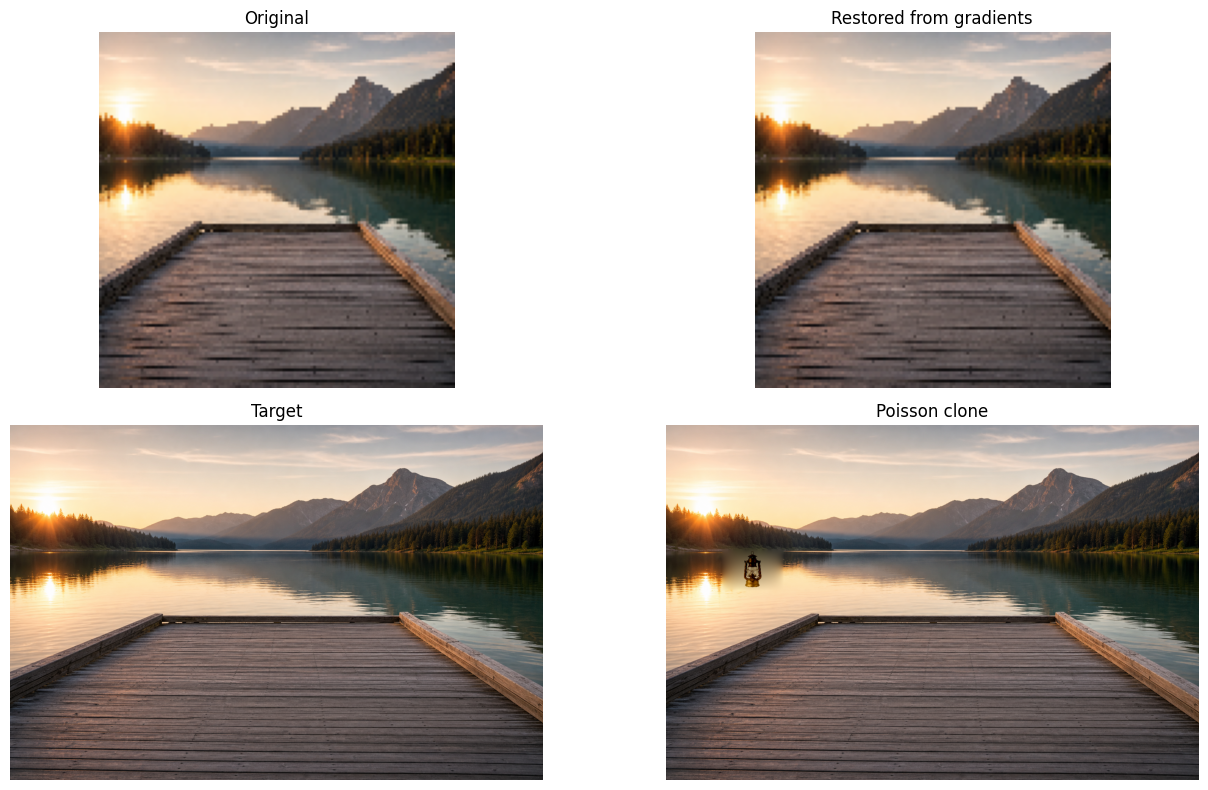

In [17]:
target = cv2.imread("lake.png")
source = cv2.imread("lamp.png")

target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)

target_small = cv2.resize(target, (128, 128))
restored = reconstruct_image(target_small)

source_small = cv2.resize(source, (180, 120))

top = 360
left = 160
cloned = poisson_clone(target, source_small, top, left)

plt.figure(figsize=(14, 8))

plt.subplot(221)
plt.imshow(target_small)
plt.title("Original")
plt.axis("off")

plt.subplot(222)
plt.imshow(restored)
plt.title("Restored from gradients")
plt.axis("off")

plt.subplot(223)
plt.imshow(target)
plt.title("Target")
plt.axis("off")

plt.subplot(224)
plt.imshow(cloned)
plt.title("Poisson clone")
plt.axis("off")

plt.tight_layout()
plt.show()